# 02 · Train EfficientNetB0 (Stage-2 Classifier)

This notebook trains the **second and final stage** of the cascaded pipeline.

| Step | What happens |
|------|--------------|
| 1    | Load dataset (same 80/20 split) |
| 2    | Build EfficientNetB0 with custom head |
| 3    | Phase 1 – train head only (base frozen) |
| 4    | Phase 2 – fine-tune last 20 layers |
| 5    | Evaluate on validation set |
| 6    | Save best model to `models/efficientnet_model.h5` |
| 7    | Plot accuracy / loss / confusion matrix |
| 8    | Grad-CAM explainability |


## 0 · Environment

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow :", tf.__version__)
print("GPUs       :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.21.0
GPUs       : []


## 1 · Configuration

In [18]:
DATA_DIR      = "../data"
MODEL_SAVE    = "../models/efficientnet_model.h5"

NUM_CLASSES   = 58
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 32
EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 10

os.makedirs("../models", exist_ok=True)

## 2 · Load dataset

In [3]:
from src.data_loader import get_data_generators, dataset_summary

summary = dataset_summary(DATA_DIR)

train_gen, val_gen, CLASS_NAMES = get_data_generators(
    data_dir   = DATA_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
)

print("Classes :", len(CLASS_NAMES))
print("First 5:", CLASS_NAMES[:5])


  Dataset Summary
  Root         : ../data
  Classes      : 58
  Total images : 94226

Found 75401 images belonging to 58 classes.
Found 18825 images belonging to 58 classes.
[data_loader] Found 58 classes.
[data_loader] Training   samples : 75401
[data_loader] Validation samples : 18825
Classes : 58
First 5: ['Apple___black_rot', 'Apple___cedar_rust', 'Apple___healthy', 'Apple___scab', 'Bell_pepper___bacterial_spot']


## 3 · Build EfficientNetB0

In [4]:
from src.efficientnet_model import build_efficientnet

model = build_efficientnet(
    num_classes = NUM_CLASSES,
    input_shape = IMAGE_SIZE + (3,),
    freeze_base = True,
)

# Sanity-check forward pass
imgs, _ = next(train_gen)
out     = model.predict(imgs[:2], verbose=0)
print("Output shape        :", out.shape)
print("Probabilities sum ≈1:", np.allclose(out.sum(axis=1), 1.0))

[efficientnet_model] Built EfficientNetB0 | classes=58 | base_frozen=True


Model: "EfficientNetB0_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)       │ (None, 7, 7, 1280)       │     4,049,571 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 58)               │        14,906 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,392,413 (16.76 MB)

 Trainable params: 342,842 (1.31 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Output shape        : (2, 58)
Probabilities sum ≈1: True


## 4 · Train – Phase 1 (head only)

In [5]:
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from src.efficientnet_model import get_callbacks

# Compute class weights to handle imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights_dict = dict(enumerate(class_weights_array))

# Make a dedicated phase1 path
path_dir = os.path.dirname(MODEL_SAVE)
base_name = os.path.basename(MODEL_SAVE)
name, ext = os.path.splitext(base_name)
MODEL_PHASE1 = os.path.join(path_dir, f"{name}_phase1{ext}")

callbacks1 = get_callbacks(MODEL_PHASE1, patience=7)

history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_PHASE1,
    callbacks       = callbacks1,
    class_weight    = class_weights_dict,
    verbose         = 1,
)

print("\nPhase 1 best val_accuracy:",
      max(history1.history["val_accuracy"]))


Epoch 1/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.5925 - loss: 1.4043
Epoch 1: val_accuracy improved from None to 0.79134, saving model to ../models\efficientnet_model_phase1.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1942s 822ms/step - accuracy: 0.6970 - loss: 0.9314 - val_accuracy: 0.7913 - val_loss: 0.6783 - learning_rate: 0.0010
Epoch 2/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.7808 - loss: 0.5577
Epoch 2: val_accuracy improved from 0.79134 to 0.81339, saving model to ../models\efficientnet_model_phase1.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1814s 770ms/step - accuracy: 0.7881 - loss: 0.5515 - val_accuracy: 0.8134 - val_loss: 0.6164 - learning_rate: 0.0010
Epoch 3/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8005 - loss: 0.5060
Epoch 3: val_accuracy did not improve from 0.81339
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1762s 748ms/step - accuracy: 0.8038 - loss: 0.4933 - val_accuracy: 0.7950 - val_loss: 0.6347 - learning_rate: 0.0010
Epoch 4/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8119 - loss: 0.4582
Epoch 4: val_accuracy improved from 0.81339 to 0.81344, saving model to ../models\efficientnet_model_phase1.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1717s 728ms/step - accuracy: 0.8130 - loss: 0.4618 - val_accuracy: 0.8134 - val_loss: 0.6052 - learning_rate: 0.0010
Epoch 5/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8181 - loss: 0.4347
Epoch 5: val_accuracy improved from 0.81344 to 0.83278, saving model to ../models\efficientnet_model_phase1.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1716s 728ms/step - accuracy: 0.8192 - loss: 0.4391 - val_accuracy: 0.8328 - val_loss: 0.5967 - learning_rate: 0.0010
Epoch 6/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.8199 - loss: 0.4393
Epoch 6: val_accuracy did not improve from 0.83278
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1711s 726ms/step - accuracy: 0.8207 - loss: 0.4353 - val_accuracy: 0.8067 - val_loss: 0.6710 - learning_rate: 0.0010
Epoch 7/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.8212 - loss: 0.4408
Epoch 7: val_accuracy improved from 0.83278 to 0.84892, saving model to ../models\efficientnet_model_phase1.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1712s 726ms/step - accuracy: 0.8239 - loss: 0.4281 - val_accuracy: 0.8489 - val_loss: 0.5763 - learning_rate: 0.0010
Epoch 8/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8300 - loss: 0.4080
Epoch 8: val_accuracy did not improve from 0.84892
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1714s 727ms/step - accuracy: 0.8295 - loss: 0.4079 - val_accuracy: 0.8484 - val_loss: 0.5459 - learning_rate: 0.0010
Epoch 9/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.8297 - loss: 0.3929
Epoch 9: val_accuracy did not improve from 0.84892
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1702s 722ms/step - accuracy: 0.8296 - loss: 0.4034 - val_accuracy: 0.8315 - val_loss: 0.6402 - learning_rate: 0.0010
Epoch 10/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.8274 - loss: 0.3946
Epoch 10: val_accuracy did not improve from 0.84892
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2010s 853ms/step - accuracy: 0.8310 - loss: 0.3943 - val_accuracy: 0.8431 - val_loss: 0.6151 - learn


Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1700s 721ms/step - accuracy: 0.8577 - loss: 0.3117 - val_accuracy: 0.8498 - val_loss: 0.6203 - learning_rate: 5.0000e-04
Epoch 15/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.8622 - loss: 0.2859
Epoch 15: val_accuracy improved from 0.84977 to 0.85673, saving model to ../models\efficientnet_model_phase1.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1872s 794ms/step - accuracy: 0.8655 - loss: 0.2819 - val_accuracy: 0.8567 - val_loss: 0.5873 - learning_rate: 2.5000e-04
Epoch 16/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8715 - loss: 0.2683
Epoch 16: val_accuracy improved from 0.85673 to 0.86024, saving model to ../models\efficientnet_model_phase1.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1701s 722ms/step - accuracy: 0.8693 - loss: 0.2718 - val_accuracy: 0.8602 - val_loss: 0.5966 - learning_rate: 2.5000e-04
Epoch 17/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8710 - loss: 0.2679
Epoch 17: val_accuracy did not improve from 0.86024

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1694s 719ms/step - accuracy: 0.8706 - loss: 0.2671 - val_accuracy: 0.8587 - val_loss: 0.5943 - learning_rate: 2.5000e-04
Epoch 18/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.8705 - loss: 0.2711
Epoch 18: val_accuracy did not improve from 0.86024
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1807s 767ms/step - accuracy: 0.8732 - loss: 0.2550 - val_accuracy: 0.8594 - val_loss: 0.5976 - learning_rate: 1.2500e-04
Epoch 19/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.8742 - loss: 0.2614
Epoch 19: val_accuracy improved from 0.86024 to 0.86364, saving model to ../models\effici

2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1863s 791ms/step - accuracy: 0.8755 - loss: 0.2578 - val_accuracy: 0.8636 - val_loss: 0.5834 - learning_rate: 1.2500e-04
Epoch 20/20
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.8764 - loss: 0.2469
Epoch 20: val_accuracy did not improve from 0.86364

Epoch 20: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 1737s 737ms/step - accuracy: 0.8764 - loss: 0.2466 - val_accuracy: 0.8630 - val_loss: 0.5790 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 19.

Phase 1 best val_accuracy: 0.8636387586593628


## 5 · Fine-tune – Phase 2 (last 20 layers)

In [6]:
from src.efficientnet_model import unfreeze_last_n_layers
import shutil

# Reload best weights from Phase 1 before fine-tuning
model.load_weights(MODEL_PHASE1)

model = unfreeze_last_n_layers(model, n_layers=60, new_lr=1e-4)

MODEL_PHASE2 = os.path.join(path_dir, f"{name}_phase2{ext}")
callbacks2 = get_callbacks(MODEL_PHASE2, patience=5)

history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_PHASE2,
    callbacks       = callbacks2,
    class_weight    = class_weights_dict,
    verbose         = 1,
)

print("\nPhase 2 best val_accuracy:",
      max(history2.history["val_accuracy"]))

# Finally, save the best overall model to MODEL_SAVE for down-stream evaluation
best_phase = 2 if max(history2.history['val_accuracy']) >= max(history1.history['val_accuracy']) else 1
best_path = MODEL_PHASE2 if best_phase == 2 else MODEL_PHASE1
shutil.copy(best_path, MODEL_SAVE)
print(f"\nSelected Phase {best_phase} as the best model and saved to {MODEL_SAVE}")


[efficientnet_model] Fine-tuning: 47 / 238 base layers trainable | lr=0.0001
Epoch 1/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.8673 - loss: 0.2897
Epoch 1: val_accuracy improved from None to 0.86486, saving model to ../models\efficientnet_model_phase2.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2005s 847ms/step - accuracy: 0.8699 - loss: 0.2791 - val_accuracy: 0.8649 - val_loss: 0.5798 - learning_rate: 1.0000e-04
Epoch 2/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.8833 - loss: 0.2359
Epoch 2: val_accuracy improved from 0.86486 to 0.86826, saving model to ../models\efficientnet_model_phase2.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2484s 1s/step - accuracy: 0.8843 - loss: 0.2383 - val_accuracy: 0.8683 - val_loss: 0.5135 - learning_rate: 1.0000e-04
Epoch 3/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8924 - loss: 0.2065
Epoch 3: val_accuracy did not improve from 0.86826
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2729s 1s/step - accuracy: 0.8920 - loss: 0.2128 - val_accuracy: 0.8671 - val_loss: 0.5371 - learning_rate: 1.0000e-04
Epoch 4/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.8966 - loss: 0.2011
Epoch 4: val_accuracy improved from 0.86826 to 0.87623, saving model to ../models\efficientnet_model_phase2.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2299s 975ms/step - accuracy: 0.8978 - loss: 0.2022 - val_accuracy: 0.8762 - val_loss: 0.4824 - learning_rate: 1.0000e-04
Epoch 5/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.9028 - loss: 0.1801
Epoch 5: val_accuracy did not improve from 0.87623
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2263s 960ms/step - accuracy: 0.9028 - loss: 0.1810 - val_accuracy: 0.8753 - val_loss: 0.4979 - learning_rate: 1.0000e-04
Epoch 6/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.9045 - loss: 0.1726
Epoch 6: val_accuracy did not improve from 0.87623
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2315s 982ms/step - accuracy: 0.9038 - loss: 0.1761 - val_accuracy: 0.8762 - val_loss: 0.5456 - learning_rate: 1.0000e-04
Epoch 7/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.9084 - loss: 0.1687
Epoch 7: val_accuracy improved from 0.87623 to 0.88733, saving model to ../models\efficientnet_model_phase2.h5



Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2650s 1s/step - accuracy: 0.9079 - loss: 0.1719 - val_accuracy: 0.8873 - val_loss: 0.4830 - learning_rate: 1.0000e-04
Epoch 8/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9145 - loss: 0.1522
Epoch 8: val_accuracy did not improve from 0.88733
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2806s 1s/step - accuracy: 0.9160 - loss: 0.1452 - val_accuracy: 0.8827 - val_loss: 0.5116 - learning_rate: 5.0000e-05
Epoch 9/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.9185 - loss: 0.1414
Epoch 9: val_accuracy improved from 0.88733 to 0.90167, saving model to ../models\efficientnet_model_phase2.h5


2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2029s 861ms/step - accuracy: 0.9191 - loss: 0.1381 - val_accuracy: 0.9017 - val_loss: 0.4718 - learning_rate: 5.0000e-05
Epoch 10/10
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.9220 - loss: 0.1350
Epoch 10: val_accuracy did not improve from 0.90167
2357/2357 ━━━━━━━━━━━━━━━━━━━━ 2026s 860ms/step - accuracy: 0.9217 - loss: 0.1346 - val_accuracy: 0.9001 - val_loss: 0.5086 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 9.

Phase 2 best val_accuracy: 0.9016733169555664

Selected Phase 2 as the best model and saved to ../models/efficientnet_model.h5


## 6 · Training curves

[utils] History plot saved → ../models/efficientnet_history.png


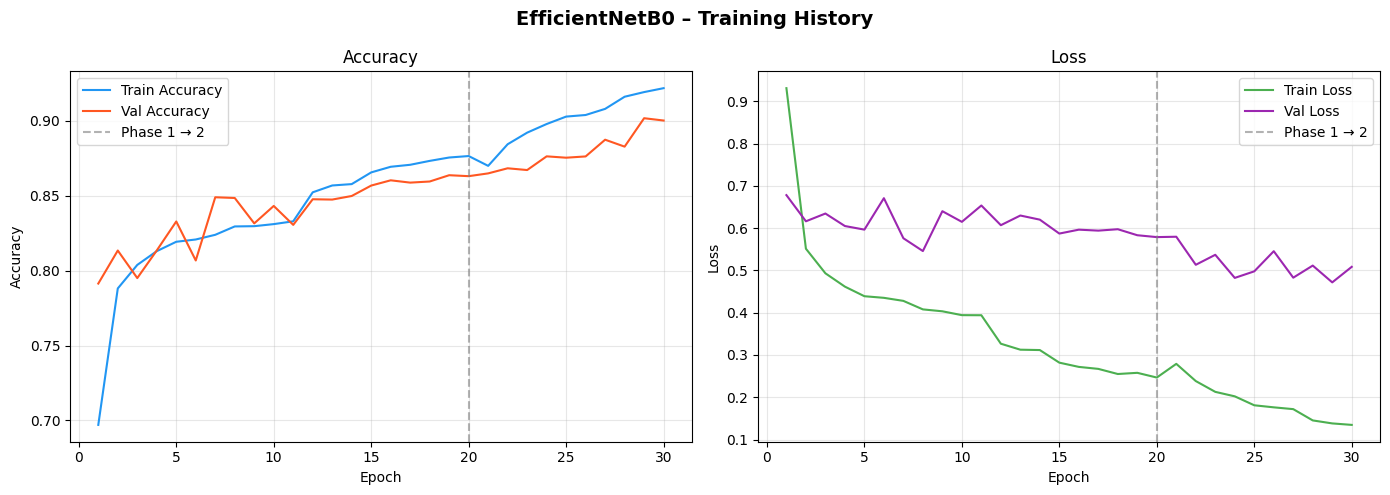

In [7]:
from src.utils import plot_training_history

plot_training_history(
    history1,
    history2,
    model_name = "EfficientNetB0",
    save_path  = "../models/efficientnet_history.png",
)

## 7 · Evaluate on validation set

In [8]:
from tensorflow.keras.models import load_model

best_model = load_model(MODEL_SAVE)

val_loss, val_acc = best_model.evaluate(val_gen, verbose=1)
print(f"\n✅  Val Loss     : {val_loss:.4f}")
print(f"✅  Val Accuracy : {val_acc:.4f}")

589/589 ━━━━━━━━━━━━━━━━━━━━ 319s 537ms/step - accuracy: 0.8355 - loss: 0.7074

✅  Val Loss     : 0.7074
✅  Val Accuracy : 0.8355


## 8 · Confusion matrix

[utils] Running predictions for confusion matrix …
[utils] Confusion matrix saved → ../models/efficientnet_confusion_matrix.png


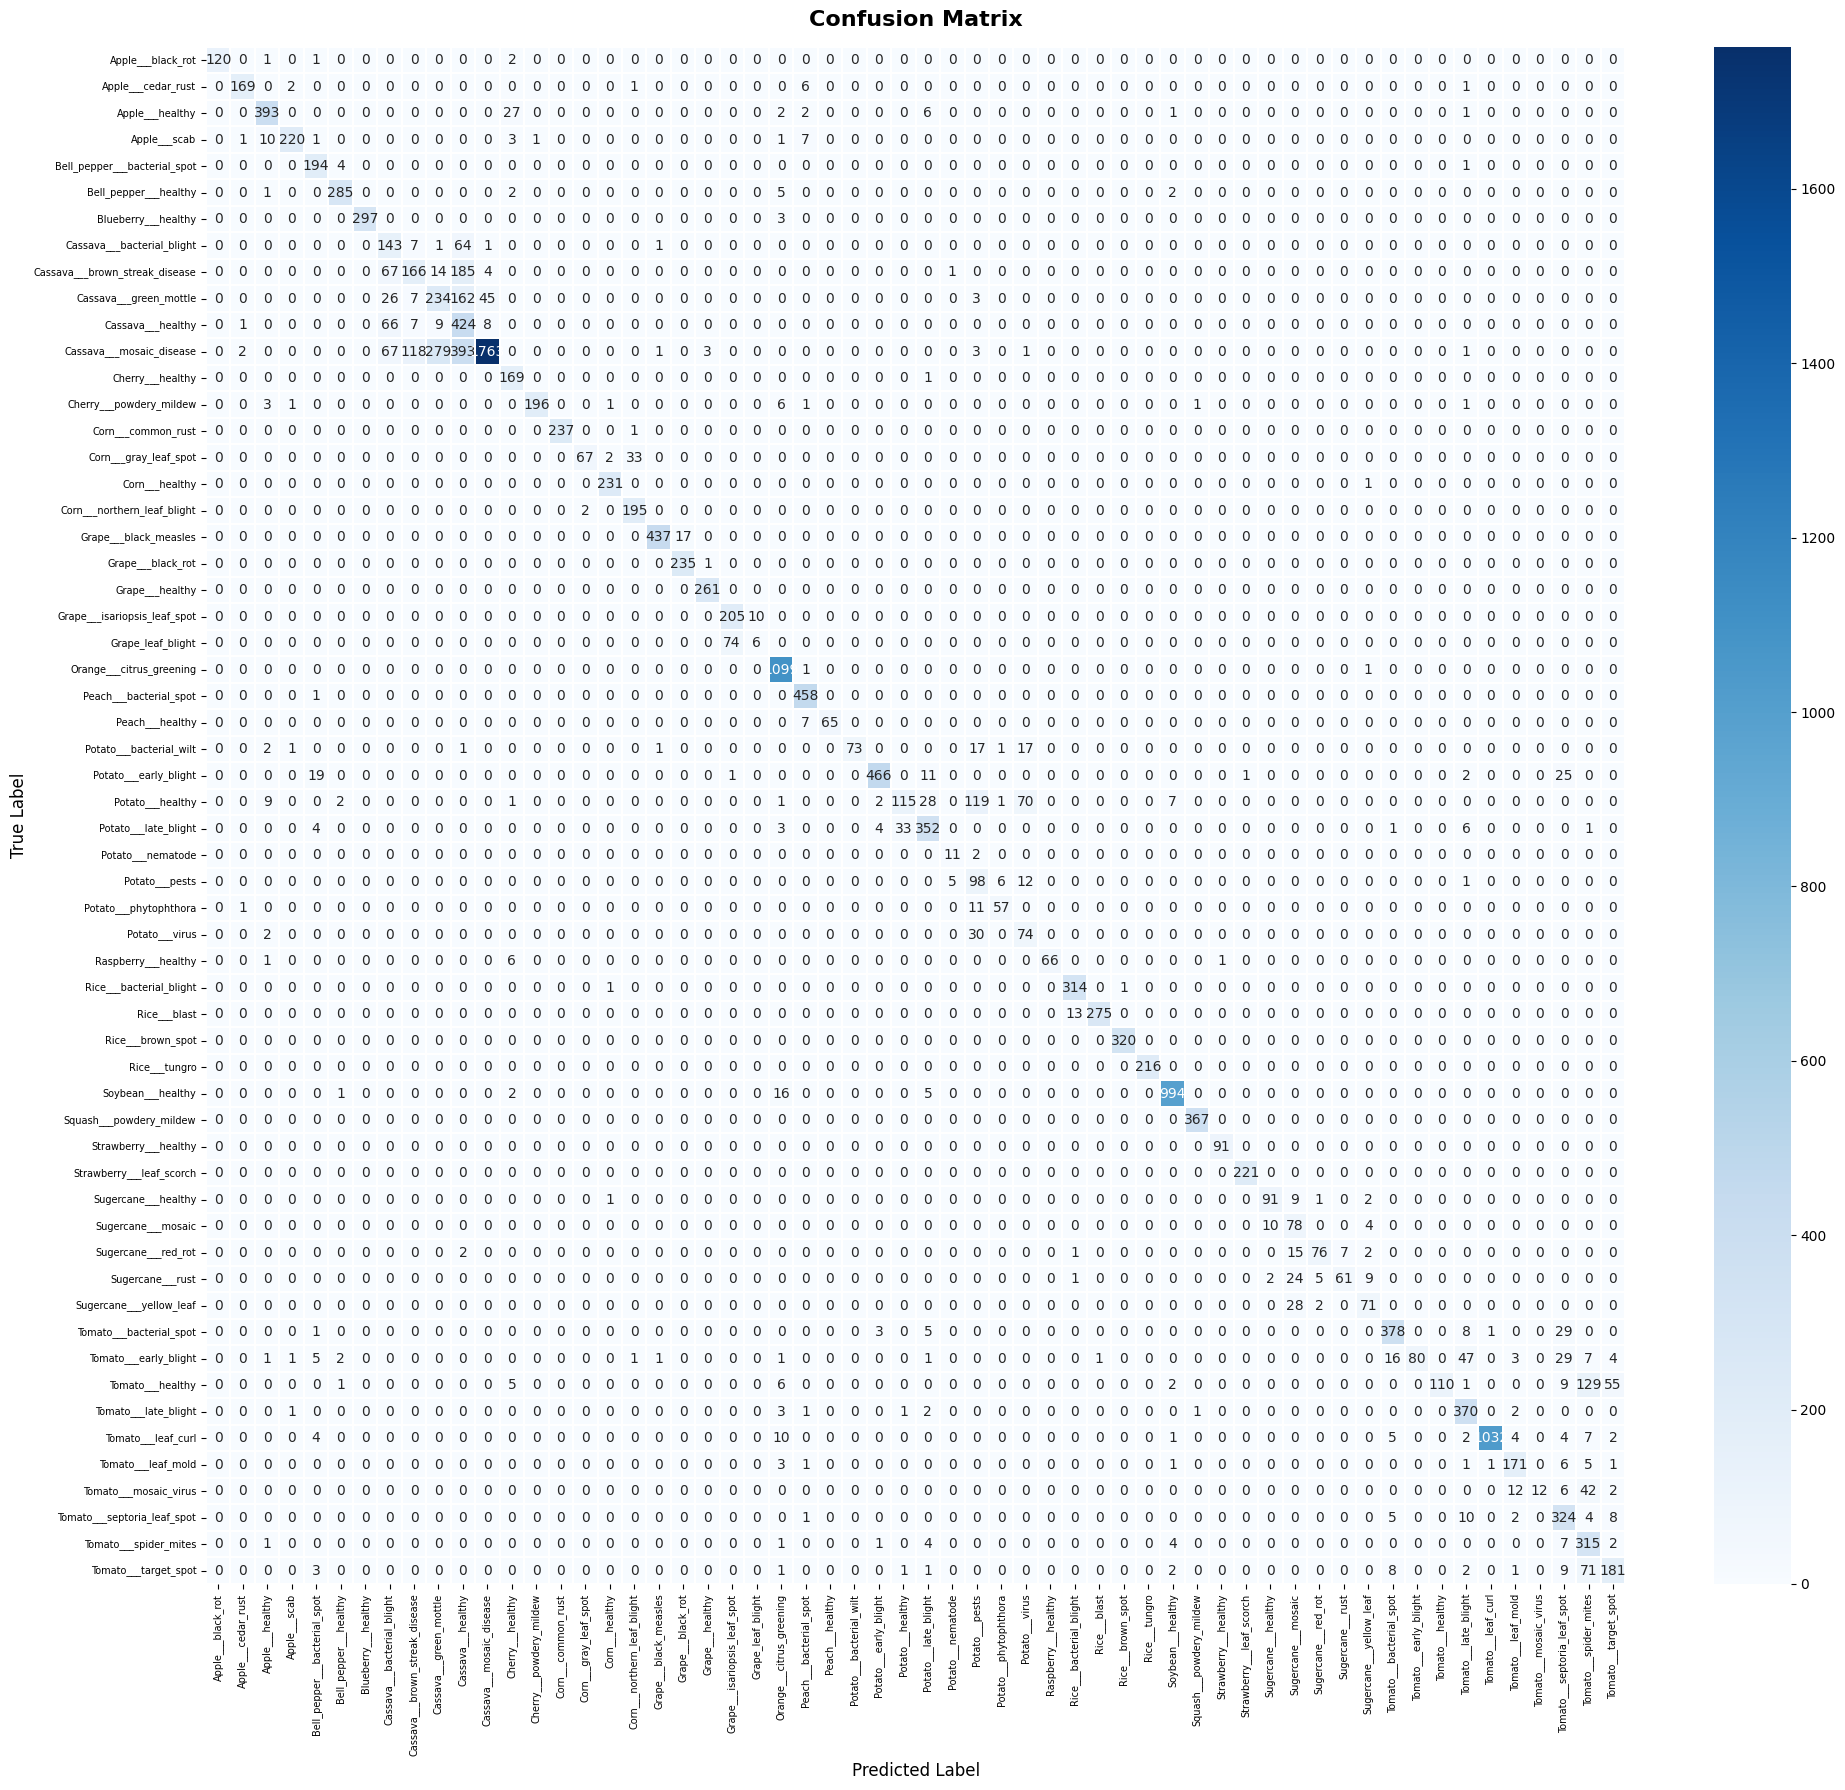


                                precision    recall  f1-score   support

             Apple___black_rot      1.000     0.968     0.984       124
            Apple___cedar_rust      0.971     0.944     0.958       179
               Apple___healthy      0.927     0.910     0.918       432
                  Apple___scab      0.973     0.902     0.936       244
  Bell_pepper___bacterial_spot      0.833     0.975     0.898       199
         Bell_pepper___healthy      0.966     0.966     0.966       295
           Blueberry___healthy      1.000     0.990     0.995       300
    Cassava___bacterial_blight      0.388     0.659     0.488       217
Cassava___brown_streak_disease      0.544     0.380     0.447       437
        Cassava___green_mottle      0.436     0.491     0.462       477
             Cassava___healthy      0.344     0.823     0.486       515
      Cassava___mosaic_disease      0.968     0.670     0.792      2631
              Cherry___healthy      0.779     0.994     0.873 

In [9]:
from src.utils import plot_confusion_matrix

val_gen.reset()
plot_confusion_matrix(
    best_model,
    val_gen,
    CLASS_NAMES,
    save_path = "../models/efficientnet_confusion_matrix.png",
)